In [1]:
import os
import torch
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

os.chdir('..')

from botorch.utils.multi_objective.box_decompositions.non_dominated import FastNondominatedPartitioning

tkwargs = {
    "dtype": torch.double,
    "device": torch.device("cuda" if torch.cuda.is_available() else "cpu"),
}

BATCH_SIZE = 10
ACQUISITION_FUNCTIONS = [
    "Random",
    "LogNParEGO",
    "LogNEHVI",
    "VarLogNEHVI"
]

REFERENCE = torch.tensor([-1,-1], **tkwargs)

In [4]:
data_path = 'data'
data = torch.load(os.path.join(data_path, 'reduced_data_k100.pt')).to(**tkwargs)
all_Y = data[:,-3:-1]

partitioning = FastNondominatedPartitioning(ref_point=REFERENCE, Y=all_Y)
pareto_Y = partitioning.pareto_Y

hv = partitioning.compute_hypervolume().item()
hv

631.1537688623735

In [5]:
def plot_pareto(all_Y, indices = False, ax = None, acq_name = None, filename = None):
    if ax is None:
        fig = plt.figure()
        ax = fig.gca()

    partitioning = FastNondominatedPartitioning(ref_point=REFERENCE, Y=all_Y)
    pareto_Y = partitioning.pareto_Y

    hv = partitioning.compute_hypervolume().item()

    ax.scatter(all_Y[:, 0].cpu(), all_Y[:, 1].cpu(), color = 'black', alpha = 0.5)
    ax.scatter(pareto_Y[:, 0].cpu(), pareto_Y[:, 1].cpu(), color='red', label='Pareto Front')
    ax.set_xlabel('Total Concentration')
    ax.set_ylabel('% Viability')
    if acq_name is not None:
        ax.set_title(f'{acq_name}, HV = {hv:.5f}')
    else:
        ax.set_title(f'Hypervolume: {hv:.5f}')
    ax.grid()

    if (filename is None) & (ax is None):
        fig.show()

def load_data(data_path, acq_name):
    # First load the initial data
    data = torch.load(os.path.join(data_path, 'reduced_data_k100.pt')).to(**tkwargs)
    # Now append all of the iterations data
    data_path = 'data'
    for file in os.listdir(os.path.join(data_path, acq_name)):
        iter_data = torch.load(os.path.join(data_path, acq_name, file)).to(**tkwargs)
        # Append each iteration to the data tensor
        data = torch.cat((data, iter_data), dim=0)

    return data

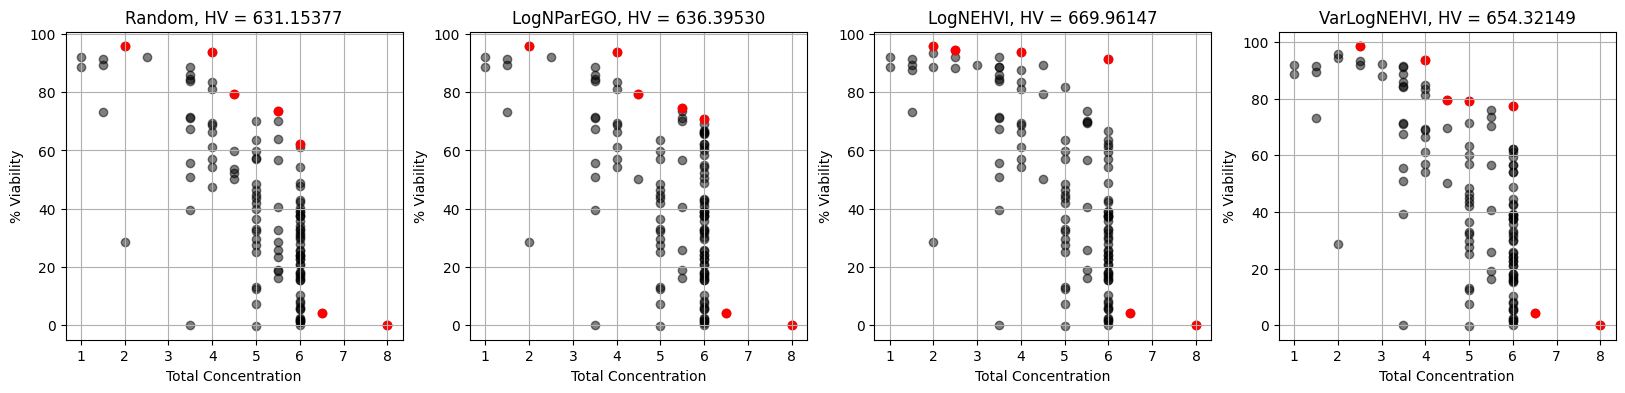

In [6]:
# Create a plot of the Pareto front for each acquisition function
fig = plt.figure(figsize=(20, 4))
ax = fig.subplots(1, len(ACQUISITION_FUNCTIONS))

for i, acq_name in enumerate(ACQUISITION_FUNCTIONS):
    # Load the data
    data_path = 'data'
    data = load_data(data_path, acq_name)
    all_Y = data[:,-3:-1]

    # Plot the Pareto front
    plot_pareto(all_Y, ax=ax[i], acq_name=acq_name)

plt.show()

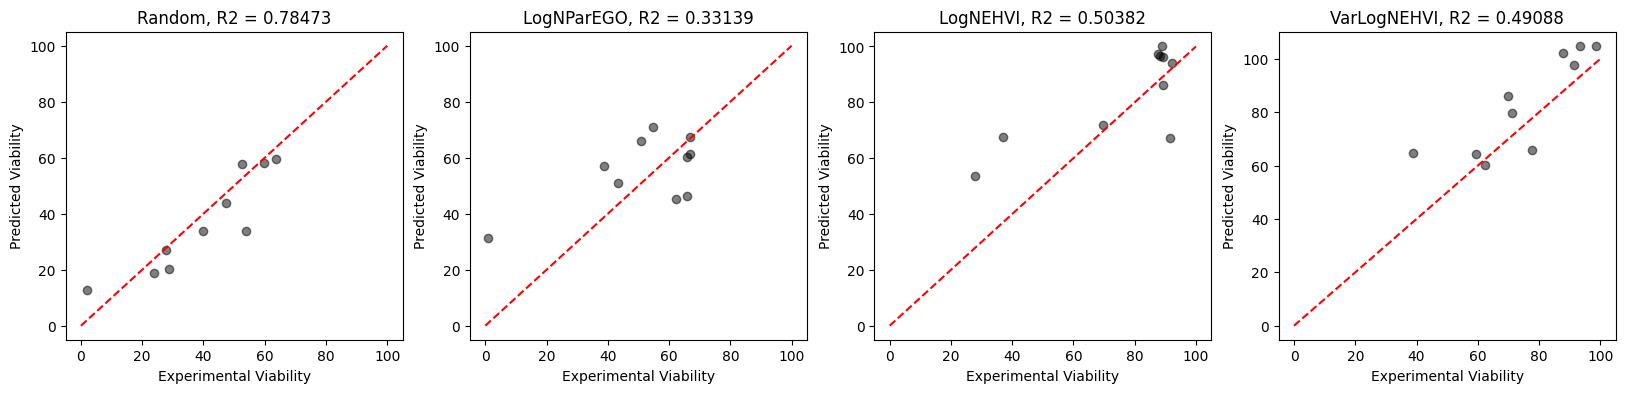

In [2]:
def plot_r2(Y_exp, Y_pred, ax = None, acq_name = None):
    if ax is None:
        fig = plt.figure()
        ax = fig.gca()
    r2 = r2_score(Y_exp, Y_pred)
    ax.scatter(Y_exp, Y_pred, color = 'black', alpha = 0.5)
    ax.plot([0, 100], [0, 100], color='red', linestyle = '--')
    ax.set_xlabel('Experimental Viability')
    ax.set_ylabel('Predicted Viability')
    if acq_name is not None:
        ax.set_title(f'{acq_name}, R2 = {r2:.5f}')
    else:
        ax.set_title(f'R2: {r2:.5f}')

# Create a plot of R2 versus iterations
iter = 2

fig = plt.figure(figsize=(20, 4))
ax = fig.subplots(1, len(ACQUISITION_FUNCTIONS))

# Load the candidates xlsx file to get the predicted viability
Y_pred = pd.read_excel(f'candidates/iteration{iter}.xlsx', usecols = ['Index', 'Predicted Viability'], index_col=0).to_numpy()
# Then parse each of the acquisition functions to yield the R2
for i, acq_name in enumerate(ACQUISITION_FUNCTIONS):
    Y_exp = torch.load(os.path.join('data', acq_name, f'iteration{iter}.pt')).to(**tkwargs)[:,-2].cpu()
    r2 = r2_score(Y_exp, Y_pred[i*BATCH_SIZE:(i+1)*BATCH_SIZE])
    # Create an R2 plot
    plot_r2(Y_exp, Y_pred[i*BATCH_SIZE:(i+1)*BATCH_SIZE], ax=ax[i], acq_name=acq_name)

plt.show()